#### Downloading CallGraph_0.csv

In [1]:

# file_id = '1l1Zebe2-r6DrL1PwbNB431RCscSu9IXz' # Replace with the actual file ID
# !gdown --id $file_id

#### Downloading MCRRT.csv

In [2]:

# file_id = '1ynXM49k1FdyzhfrFPxnZI4_HXO8k58cy' # Replace with the actual file ID
# !gdown --id $file_id

#### Downloading MSMetrics.csv

In [3]:
# file_id = '1sZutUdbaWdmD3DqaNW-Zv6kjPSXD17tZ' # Replace with the actual file ID
# !gdown --id $file_id

#### Downloading NodeMetrics.csv

In [4]:
# file_id = '1k7w6pgM9GL6F78LzBf_jgVU-i500nIkV' # Replace with the actual file ID
# !gdown --id $file_id

### Required Modules

In [5]:
import matplotlib.pyplot as plt
import pandas as pd 

### Reading all .CSV Files
##### 1. MicroService_Metrics ---> ms_metric
##### 2. MC_RRT ---> mc_rrt
##### 3. Node Metrics ---> node_metric
##### 4. CallGraph --> callgraph

In [6]:
ms_metric = pd.read_csv('MSMetricsUpdate_0.csv',on_bad_lines='skip')

In [7]:
mc_rrt = pd.read_csv('MCRRTUpdate_0.csv',on_bad_lines='skip') 

In [8]:
node_metric = pd.read_csv('NodeMetricsUpdate_0.csv',on_bad_lines='skip')

In [9]:
call_graph = pd.read_csv('CallGraph_0.csv',on_bad_lines='skip')

In [10]:
# try:
#     callp = call_graph
#     nodem = node_metric
#     msmetric = ms_metric
#     mcrrt = mc_rrt
# except: 
#     raise Exception("Error")

In [11]:
# print(callp.shape,'\n',
# msmetric.shape,'\n',
# mcrrt.shape)

### Pre-Processing

### Columns of dataset
#### 1. Call_graph: 
Index(['timestamp', 'traceid', 'service', 'rpc_id', 'rpctype', 'um',
       'uminstanceid', 'interface', 'dm', 'dminstanceid', 'rt'],
      dtype='object')

#### 2. MS_Metric
Index(['timestamp', 'msname', 'msinstanceid', 'nodeid', 'cpu_utilization',
       'memory_utilization'],
      dtype='object')


#### 3. MCRRT 
Index(['timestamp', 'msname', 'msinstanceid', 'nodeid', 'providerrpc_rt',
       'providerrpc_mcr', 'consumerrpc_rt', 'consumerrpc_mcr', 'writemc_rt',
       'writemc_mcr', 'readmc_rt', 'readmc_mcr', 'writedb_rt', 'writedb_mcr',
       'readdb_rt', 'readdb_mcr', 'consumermq_rt', 'consumermq_mcr',
       'providermq_rt', 'providermq_mcr', 'http_mcr', 'http_rt'],
      dtype='object')

#### 4. Node Metric
Index(['timestamp', 'nodeid', 'cpu_utilization', 'memory_utilization'], dtype='object')




#### Sample 350K file to build Model

In [12]:
# sample_df = call_graph.sample(n=350000, random_state=42)

# sample_df.to_csv("CallGraph_350k.csv", index=False)


#### Building rest of 350K based on Callgraph

In [13]:
call_sample = pd.read_csv('CallGraph_350k.csv')

In [14]:
call_sample.head(10)

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
0,76237,T_21388589380,S_115042431,0.1.3.27,mc,MS_48385,MS_48385_POD_3776,j9JPeZqdfa,MS_14728,UNKNOWN,0.0
1,104310,T_4767157225,S_104419129,0.1.2.15,mc,MS_4660,MS_4660_POD_2652,27LLHBLtvK,MS_46825,MS_46825_POD_289,1.0
2,35589,T_19429784845,S_58367703,0.1.1.6,mq,MS_19279,MS_19279_POD_91,hMOAwKKkMh,MS_30234,MS_30234_POD_76,0.0
3,80083,T_8925144016,S_80466277,0.1.1.2.1.56.1,mc,MS_51052,MS_51052_POD_2061,K7owOgUd1X,MS_66332,MS_66332_POD_40,0.0
4,44789,T_3037066685,S_104419129,0.1.2.5,mc,MS_4660,MS_4660_POD_1359,ScFx7XudDg,MS_55085,MS_55085_POD_700,0.0
5,119818,T_18910370216,S_156482560,0.1,http,UNKNOWN,UNAVAILABLE,bHiJXTZtx1,MS_40912,MS_40912_POD_303,2.0
6,47190,T_19194028381,S_51794709,0,http,USER,USER,Rs4VbRVJj2,MS_42200,MS_42200_POD_672,0.0
7,141995,T_10104064984,S_157704810,0.1.1.2.1.47,mc,MS_51052,MS_51052_POD_412,NbWtDAnQop,MS_24560,MS_24560_POD_1,0.0
8,113477,T_4005675566,S_84744291,0.1.2.7,mc,MS_20820,MS_20820_POD_289,CZYUPBqany,MS_37691,MS_37691_POD_3241,1.0
9,143478,T_18047655436,S_100293104,0.959,db,MS_36146,MS_36146_POD_9,mJxUT-THwr,MS_27421,UNKNOWN,0.0


##### Filtered Metrics File

In [15]:
# um_instances = set(call_sample['uminstanceid'].dropna())
# dm_instances = set(call_sample['dminstanceid'].dropna())

# all_instances = um_instances.union(dm_instances)

# print("Total unique instances", len(all_instances))

# filtered_msmetrics = msmetric[
#     msmetric['msinstanceid'].isin(all_instances)
# ]

# filtered_msmetrics.to_csv("Filtered_MSMetrics.csv", index=False)

# print("Filtered MSMetrics file created successfully")

In [16]:
# um_instances = set(call_sample['uminstanceid'].dropna())
# dm_instances = set(call_sample['dminstanceid'].dropna())

# all_instances = um_instances.union(dm_instances)

# print("Total unique instances from CallGraph:", len(all_instances))

# filtered_mcrrt = mc_rrt[
#     mc_rrt['msinstanceid'].isin(all_instances)
# ]
# filtered_mcrrt.to_csv("Filtered_mc_rrt.csv", index=False)

# print("Filtered MCRRT file created successfully")

In [17]:
# um_instances = set(filtered_msmetrics['nodeid'].dropna())
# dm_instances = set(filtered_mcrrt['nodeid'].dropna())

# all_instances = um_instances.union(dm_instances)

# print("Total unique nodeid:", len(all_instances))

# filtered_nodemetric = node_metric[
#     node_metric['nodeid'].isin(all_instances)
# ]

# filtered_nodemetric.to_csv("Filtered_NodeMetric.csv", index=False)

# print("Filtered NodeMetric file created successfully")

#### PRE-PROCESSING


In [18]:
call_sample = pd.read_csv('CallGraph_350k.csv')
ms_sample = pd.read_csv('Filtered_MSMetrics.csv')
msrrt_sample = pd.read_csv('Filtered_mc_rrt.csv')
node_sample = pd.read_csv('Filtered_NodeMetric.csv')

In [19]:
len(call_sample['service'].unique())

21475

In [20]:
'UNKNOWN' in call_sample['service'].unique()

False

#### Averge CAllGraph Length

In [21]:
print("Avergae Call Graph Length: ",call_sample['traceid'].count()//call_sample['service'].nunique())

Avergae Call Graph Length:  16


##### Grouping based on Trace_Id and accessing data of User 

In [22]:
grouped_traces = call_sample.groupby('traceid')

In [23]:
with_user = call_sample.loc[call_sample['um'] == 'USER']['traceid'].unique()

In [24]:
len(with_user)

27553

#### Grouping based on TimeStamp

In [25]:
group_timestamp = call_sample.groupby('timestamp')

In [26]:
# ms_metric.head(10)

In [27]:
idx = list(group_timestamp.groups.keys())[0]

In [28]:
group_timestamp.get_group(idx)

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
307134,0,T_16385369378,S_74456438,0.1.2,rpc,MS_902,MS_902_POD_66,EZI-y6gvJR,MS_902,MS_902_POD_66,191.0


In [29]:
cpu_data = ms_sample.groupby('msname')['cpu_utilization'].mean().reset_index()
cpu_data.rename(columns={'cpu_utilization': 'avg_cpu'}, inplace=True)

In [30]:
cpu_data.head(6)

,msname,avg_cpu
0,MS_10042,0.026301
1,MS_10054,0.086676
2,MS_10064,0.022689
3,MS_10097,0.200977
4,MS_10117,0.090588
5,MS_10180,0.005469


In [31]:
rt_data = call_sample.groupby('um')['rt'].mean().reset_index()
rt_data.rename(columns={'um': 'msname', 'rt': 'avg_rt'}, inplace=True)

In [32]:
rt_data = msrrt_sample.groupby('msname')['providerrpc_rt'].mean().reset_index()
rt_data.rename(columns={'msname': 'msname', 'providerrpc_rt': 'avg_rt'}, inplace=True)

In [33]:
rt_data.head(6) 

,msname,avg_rt
0,MS_10042,796.888889
1,MS_10054,0.000000
2,MS_10064,0.559084
3,MS_10077,2.972453
4,MS_10090,0.000000
5,MS_10097,91.545726


In [34]:
merged = pd.merge(cpu_data, rt_data, on='msname', how='inner')
print(merged.head())

     msname   avg_cpu      avg_rt
0  MS_10042  0.026301  796.888889
1  MS_10054  0.086676    0.000000
2  MS_10064  0.022689    0.559084
3  MS_10097  0.200977   91.545726
4  MS_10117  0.090588    0.000000


In [35]:
correlation = merged['avg_cpu'].corr(merged['avg_rt'])

print("Correlation between CPU and Response Time:", correlation)

Correlation between CPU and Response Time: 0.031247834563585052


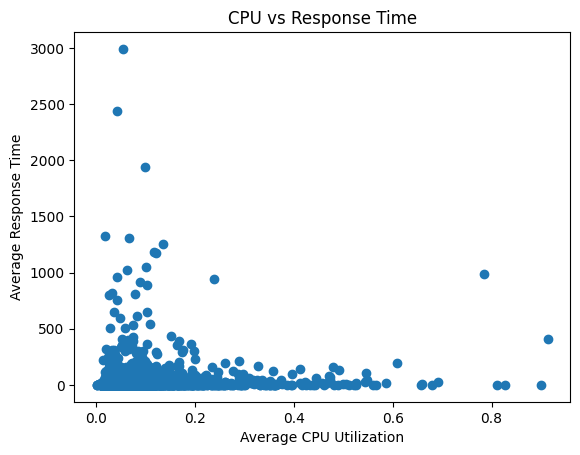

In [36]:
plt.scatter(merged['avg_cpu'], merged['avg_rt'])
plt.xlabel("Average CPU Utilization")
plt.ylabel("Average Response Time")
plt.title("CPU vs Response Time")
plt.show()

In [37]:
ms_sample

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
0,660000,MS_14240,MS_14240_POD_1,NODE_26160,0.182802,0.670019
1,1620000,MS_17325,MS_17325_POD_2,NODE_22630,0.076700,0.400587
2,120000,MS_30441,MS_30441_POD_110,NODE_8234,0.107183,0.663900
3,480000,MS_37587,MS_37587_POD_1,NODE_26266,0.032000,0.513144
4,1440000,MS_308,MS_308_POD_23,NODE_5133,0.127890,0.869812
...,...,...,...,...,...,...
167745,180000,MS_15850,MS_15850_POD_68,NODE_434,0.163066,0.462200
167746,1140000,MS_45296,MS_45296_POD_161,NODE_8909,0.144417,0.845301
167747,1740000,MS_45296,MS_45296_POD_161,NODE_8909,0.170125,0.845569
167748,960000,MS_9208,MS_9208_POD_13,NODE_42645,0.064083,0.705135


In [38]:
mem_data = ms_sample.groupby('msname')['memory_utilization'].mean().reset_index()
mem_data.rename(columns={'memory_utilization': 'avg_mem'}, inplace=True)

In [39]:
merged = pd.merge(mem_data, rt_data, on='msname', how='inner')
print(merged.head())

     msname   avg_mem      avg_rt
0  MS_10042  0.474451  796.888889
1  MS_10054  0.476175    0.000000
2  MS_10064  0.921446    0.559084
3  MS_10097  0.667304   91.545726
4  MS_10117  0.470847    0.000000


In [40]:
correlation = merged['avg_mem'].corr(merged['avg_rt'])

print("Correlation between Memory and Response Time:", correlation)

Correlation between Memory and Response Time: 0.05151992340945537


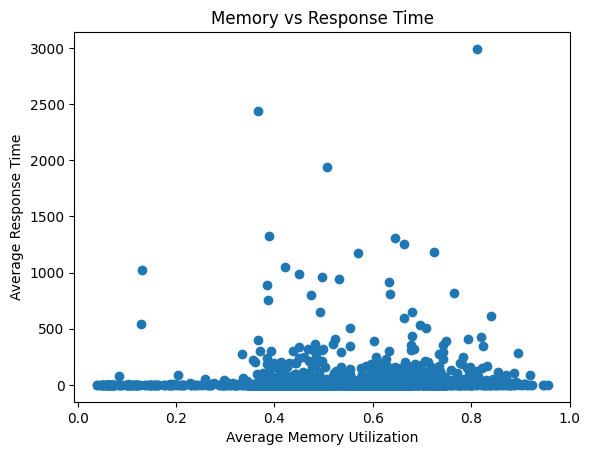

In [41]:
plt.scatter(merged['avg_mem'], merged['avg_rt'])
plt.xlabel("Average Memory Utilization")
plt.ylabel("Average Response Time")
plt.title("Memory vs Response Time")
plt.show()

In [42]:
group_node_resource = ms_sample.groupby(['nodeid','timestamp']).agg({'cpu_utilization':'mean','memory_utilization':'mean'}).reset_index()

In [43]:
group_node_resource['resource_contention'] = (
    group_node_resource['cpu_utilization'] + group_node_resource['memory_utilization']
) / 2


In [44]:
top_10_nodes = group_node_resource.sort_values(by='resource_contention', ascending=False).head(50)

In [45]:
top_10_nodes.head(10)

,nodeid,timestamp,cpu_utilization,memory_utilization,resource_contention
115456,NODE_42879,180000,0.985725,0.899930,0.942828
43794,NODE_22855,0,0.964395,0.892312,0.928353
63297,NODE_27845,420000,0.971400,0.875807,0.923603
43795,NODE_22855,240000,0.948060,0.892716,0.920388
118904,NODE_43888,60000,0.968940,0.869887,0.919413
67977,NODE_29234,360000,0.949410,0.886322,0.917866
43805,NODE_22855,840000,0.936405,0.892124,0.914264
90422,NODE_3566,360000,0.948555,0.879800,0.914177
67858,NODE_29199,60000,0.935100,0.891390,0.913245
54542,NODE_25662,240000,0.999960,0.811328,0.905644


In [46]:
high_resource_service = ms_sample[ms_sample['nodeid'].isin(top_10_nodes['nodeid'])]['msname'].unique()

In [47]:
high_call_graph = call_sample[call_sample['um'].isin(high_resource_service)].groupby('rpctype').agg({'rt':'mean'}).reset_index()

In [48]:
high_call_graph  

,rpctype,rt
0,db,1.200000
1,http,49.652174
2,mc,0.679739
3,rpc,3.727273


Text(0, 0.5, 'Average Response Time')

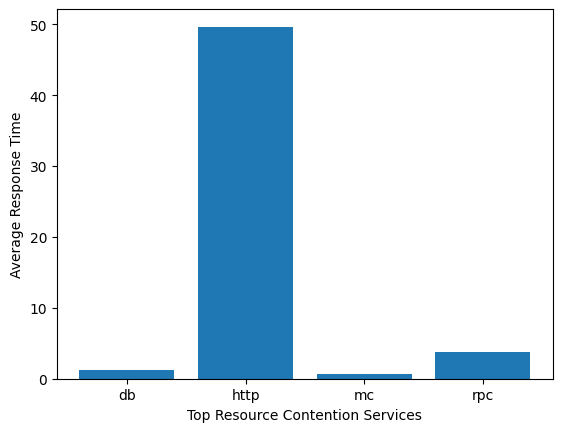

In [49]:
plt.bar(high_call_graph['rpctype'], high_call_graph['rt'])
plt.xlabel("Top Resource Contention Services")
plt.ylabel("Average Response Time")    

In [50]:
top = call_sample[call_sample['rpctype'] == 'http'].sort_values(by='rt',ascending=False)

In [51]:
top['um'].nunique()

196

In [52]:
reducing_rt = call_sample[call_sample['um'].isin(top['um'].unique())]

In [53]:
reducing_rt.dropna()

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
5,119818,T_18910370216,S_156482560,0.1,http,UNKNOWN,UNAVAILABLE,bHiJXTZtx1,MS_40912,MS_40912_POD_303,2.0
6,47190,T_19194028381,S_51794709,0,http,USER,USER,Rs4VbRVJj2,MS_42200,MS_42200_POD_672,0.0
11,3024,T_15276019308,S_32028218,0,rpc,USER,USER,KLH0K5XWXZ,MS_15600,MS_15600_POD_133,106.0
13,30051,T_19213371215,S_148215822,0.1,http,UNKNOWN,UNAVAILABLE,uaQkjcKjKX,MS_61924,MS_61924_POD_150,567.0
17,66089,T_5911143406,S_99592202,0.1.1,http,UNKNOWN,UNAVAILABLE,9-kMoEGwis,MS_745,MS_745_POD_1085,190.0
...,...,...,...,...,...,...,...,...,...,...,...
349969,144397,T_20040839075,S_111082932,0.1,http,UNKNOWN,UNAVAILABLE,NZz-DOZiUf,MS_49907,MS_49907_POD_114,0.0
349992,2743,T_565536713,S_31816608,0.1.2.1.4.1.2,rpc,MS_15934,MS_15934_POD_229446,446tkb6HWR,UNKNOWN,UNKNOWN,1.0
349996,141157,T_17406819261,S_144019174,0.1,http,UNKNOWN,UNAVAILABLE,SkHqn2uSDu,MS_49907,MS_49907_POD_34,0.0
349997,41045,T_25103699032,S_44626825,0.1,http,UNKNOWN,UNAVAILABLE,VNle3q_GFk,MS_17847,MS_17847_POD_24,0.0


### Identifying What takes More Response Time

#### Response Time of MicroServices

In [54]:
um_response = call_sample.groupby('traceid')['rt'].mean()

In [55]:
traceids = um_response.sort_values(ascending = False).head(1000).to_frame().reset_index()

In [56]:
traceids['traceid']

0       T_7067397606
1       T_1104049201
2      T_24002263933
3       T_6033888337
4       T_5219068661
           ...      
995    T_11193156951
996    T_23128335639
997    T_19020730772
998      T_879584650
999     T_2611223258
Name: traceid, Length: 1000, dtype: str

In [57]:
high_rt = call_sample[call_sample['traceid'].isin(traceids['traceid'])]

#### Finding Out the avg response time of the rpctype

In [58]:
rpc_rt = high_rt.groupby('rpctype')['rt'].mean().reset_index()

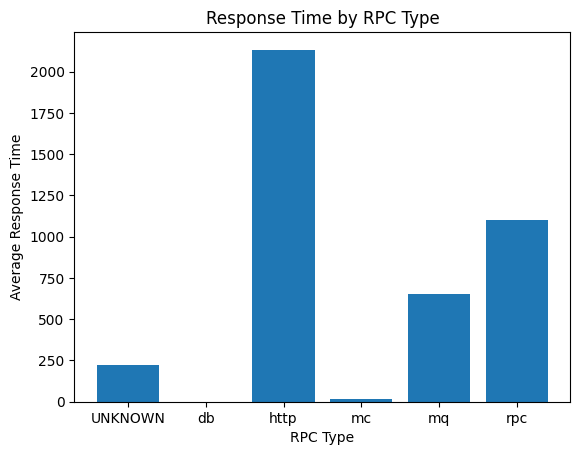

In [59]:
plt.bar(rpc_rt['rpctype'], rpc_rt['rt'])
plt.xlabel("RPC Type")
plt.ylabel("Average Response Time")
plt.title("Response Time by RPC Type")
plt.show()

### Finally Found Out HTTP is getting Late Response Time Bloody Bitch!! So let's help her

In [60]:
http_calls = call_sample[call_sample['rpctype'] == 'http']

In [61]:
http_calls  

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
5,119818,T_18910370216,S_156482560,0.1,http,UNKNOWN,UNAVAILABLE,bHiJXTZtx1,MS_40912,MS_40912_POD_303,2.0
6,47190,T_19194028381,S_51794709,0,http,USER,USER,Rs4VbRVJj2,MS_42200,MS_42200_POD_672,0.0
13,30051,T_19213371215,S_148215822,0.1,http,UNKNOWN,UNAVAILABLE,uaQkjcKjKX,MS_61924,MS_61924_POD_150,567.0
17,66089,T_5911143406,S_99592202,0.1.1,http,UNKNOWN,UNAVAILABLE,9-kMoEGwis,MS_745,MS_745_POD_1085,190.0
20,138948,T_3735163354,S_130831269,0,http,USER,USER,KFUG835JJw,MS_42200,MS_42200_POD_1218,0.0
...,...,...,...,...,...,...,...,...,...,...,...
349954,121525,T_16510613880,S_124618940,0.1,http,UNKNOWN,UNAVAILABLE,UxNjZWYt7H,MS_5182,MS_5182_POD_55,4.0
349969,144397,T_20040839075,S_111082932,0.1,http,UNKNOWN,UNAVAILABLE,NZz-DOZiUf,MS_49907,MS_49907_POD_114,0.0
349996,141157,T_17406819261,S_144019174,0.1,http,UNKNOWN,UNAVAILABLE,SkHqn2uSDu,MS_49907,MS_49907_POD_34,0.0
349997,41045,T_25103699032,S_44626825,0.1,http,UNKNOWN,UNAVAILABLE,VNle3q_GFk,MS_17847,MS_17847_POD_24,0.0


In [62]:
import numpy as np

In [63]:
call_graph_cleaned = http_calls[~(http_calls == 'UNKNOWN').any(axis=1)]
http_calls = http_calls.replace('UNKNOWN', np.nan).dropna()

In [64]:
http_calls = http_calls[http_calls['um']!='USER']

In [65]:
http_calls

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
86,96821,T_9869940019,S_109493713,0.1.1,http,MS_38945,MS_38945_POD_291,piYhf48Wvj,MS_30732,MS_30732_POD_0,0.0
193,148741,T_9000759474,S_45198898,0.1,http,MS_2087,MS_2087_POD_43,X6lB0MHIH5,MS_55966,MS_55966_POD_33,1.0
405,71119,T_19868867281,S_120554337,0.1.1.1,http,MS_42492,MS_42492_POD_80,Wn145WrzCg,MS_70114,MS_70114_POD_63,114.0
588,2979,T_16583595244,S_64976366,0.2.2,http,MS_71605,MS_71605_POD_778,dgP0D4uFSo,MS_23205,MS_23205_POD_444,14.0
627,73631,T_3787551256,S_7098525,0.1.1.1,http,MS_4990,MS_4990_POD_1646,Bq4DlpMUPJ,MS_6908,MS_6908_POD_411,10.0
...,...,...,...,...,...,...,...,...,...,...,...
349441,40354,T_6842691930,S_14022900,0.1.1,http,MS_745,MS_745_POD_2520,vuaYbAfGVO,MS_18961,MS_18961_POD_5,7.0
349442,131255,T_2422733834,S_43317168,0.1.1.1,http,MS_68938,MS_68938_POD_232,xXvS2FnVC-,MS_31900,MS_31900_POD_39,0.0
349523,141778,T_10632558368,S_118158836,0.1.1,http,MS_4990,MS_4990_POD_1236,TQXobR6THC,MS_43101,MS_43101_POD_38,2.0
349817,112614,T_7325756955,S_126027253,0.2,http,MS_23806,MS_23806_POD_118,ldTyZ-bWAP,MS_38938,MS_38938_POD_91,3.0


In [66]:
node_sample.head(5)

,timestamp,nodeid,cpu_utilization,memory_utilization
0,33240000,NODE_13142,0.351628,0.295197
1,33240000,NODE_10037,0.191076,0.180499
2,33180000,NODE_8917,0.352710,0.777048
3,33180000,NODE_28786,0.107666,0.139502
4,33180000,NODE_1868,0.153397,0.174077


In [67]:
ms_sample.head(5)

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
0,660000,MS_14240,MS_14240_POD_1,NODE_26160,0.182802,0.670019
1,1620000,MS_17325,MS_17325_POD_2,NODE_22630,0.076700,0.400587
2,120000,MS_30441,MS_30441_POD_110,NODE_8234,0.107183,0.663900
3,480000,MS_37587,MS_37587_POD_1,NODE_26266,0.032000,0.513144
4,1440000,MS_308,MS_308_POD_23,NODE_5133,0.127890,0.869812


In [68]:
msrrt_sample.head(5)

,timestamp,msname,msinstanceid,nodeid,providerrpc_rt,providerrpc_mcr,consumerrpc_rt,consumerrpc_mcr,writemc_rt,writemc_mcr,...,writedb_rt,writedb_mcr,readdb_rt,readdb_mcr,consumermq_rt,consumermq_mcr,providermq_rt,providermq_mcr,http_mcr,http_rt
0,60000,MS_32772,MS_32772_POD_2,NODE_9615,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.181818,1.080267e-07,0.000000,0.000000,0.000000e+00,0.000000
1,0,MS_73179,MS_73179_POD_22,NODE_1955,5.358554,0.000020,16.888889,1.200733e-11,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
2,60000,MS_41068,MS_41068_POD_15,NODE_36877,23.815574,0.000017,58.387097,9.883626e-12,0.000000,0.000000,...,0.983157,0.000034,0.966334,0.000044,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00,0.000000
3,0,MS_23174,MS_23174_POD_3,NODE_45340,19.618846,0.000023,11.298297,1.363339e-11,0.525123,0.000010,...,0.000000,0.000000,0.793103,0.000001,19.049180,2.995287e-06,1.513761,0.000001,1.669504e-07,0.222222
4,120000,MS_40586,MS_40586_POD_123,NODE_12749,5.051596,0.000356,9.009080,2.100618e-10,0.588530,0.000029,...,1.895911,0.000003,0.759735,0.000046,61.500000,1.964123e-08,2.892857,0.000001,0.000000e+00,0.000000


### Grouping the http Calls based on traceid to get the response rate

In [69]:
http_calls.head(5)

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
86,96821,T_9869940019,S_109493713,0.1.1,http,MS_38945,MS_38945_POD_291,piYhf48Wvj,MS_30732,MS_30732_POD_0,0.0
193,148741,T_9000759474,S_45198898,0.1,http,MS_2087,MS_2087_POD_43,X6lB0MHIH5,MS_55966,MS_55966_POD_33,1.0
405,71119,T_19868867281,S_120554337,0.1.1.1,http,MS_42492,MS_42492_POD_80,Wn145WrzCg,MS_70114,MS_70114_POD_63,114.0
588,2979,T_16583595244,S_64976366,0.2.2,http,MS_71605,MS_71605_POD_778,dgP0D4uFSo,MS_23205,MS_23205_POD_444,14.0
627,73631,T_3787551256,S_7098525,0.1.1.1,http,MS_4990,MS_4990_POD_1646,Bq4DlpMUPJ,MS_6908,MS_6908_POD_411,10.0


In [70]:
dm_group = http_calls.groupby(['traceid'])['rt'].sum().reset_index()

In [71]:
sorted_calls = dm_group.sort_values(by='rt',ascending=False).head(350)

### Finding whether 

In [72]:
sorted_calls

,traceid,rt
2675,T_9711073466,503.0
2189,T_5638612578,445.0
1508,T_22889761847,352.0
2327,T_6819668990,351.0
372,T_13245063790,347.0
...,...,...
2472,T_8127369376,53.0
2524,T_8546225565,53.0
2160,T_5365788837,53.0
2471,T_8114795613,53.0


### 

In [73]:
sorted_calls_join = pd.merge(http_calls,sorted_calls,on='traceid',how='inner')

In [74]:
sorted_calls_join

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt_x,rt_y
0,71119,T_19868867281,S_120554337,0.1.1.1,http,MS_42492,MS_42492_POD_80,Wn145WrzCg,MS_70114,MS_70114_POD_63,114.0,114.0
1,20640,T_1005341274,S_1110164,0.1.1.1,http,MS_745,MS_745_POD_2589,T9ssw6R49s,MS_40545,MS_40545_POD_18,86.0,86.0
2,171374,T_3616993117,S_14576883,0.1.1.1,http,MS_745,MS_745_POD_1385,OJ7UA7GYBo,MS_44914,MS_44914_POD_14,75.0,75.0
3,76013,T_3073311163,S_118158836,0.1.1,http,MS_39564,MS_39564_POD_1807,TQXobR6THC,MS_43101,MS_43101_POD_10,57.0,57.0
4,78041,T_8568753250,S_55282613,0.1.1.1,http,MS_745,MS_745_POD_1403,NiH3Ncd681,MS_55798,MS_55798_POD_35,89.0,89.0
...,...,...,...,...,...,...,...,...,...,...,...,...
349,92320,T_23298986850,S_16376523,0.1.1.1,http,MS_39564,MS_39564_POD_1007,uqJTeVoUvY,MS_26994,MS_26994_POD_52,61.0,61.0
350,106541,T_19629537719,S_104983050,0.1.1,http,MS_745,MS_745_POD_1555,YaHsbyxFmH,MS_44065,MS_44065_POD_65,97.0,97.0
351,114297,T_4548615098,S_134320762,0.1.1,http,MS_745,MS_745_POD_584,fZycTj61-L,MS_33778,MS_33778_POD_192,99.0,99.0
352,48770,T_12861494068,S_27863925,0.1.1,http,MS_745,MS_745_POD_1748,d8V0hkmDSl,MS_53444,MS_53444_POD_14,103.0,103.0


### Grouping based on dm to gind out whether response rate is due to high request rate

In [75]:
sorted_calls_join['window'] = (sorted_calls_join['timestamp'] // 60000) * 60000

# 2. Select relevant columns from MSMetric
# We include msinstanceid as a join key to ensure we match the specific container
ms_metric_subset = ms_sample[[
    'timestamp', 'msinstanceid', 'cpu_utilization', 'memory_utilization'
]]

# 3. Create the new merged DataFrame
# We join on the Upstream Instance (uminstanceid) and the Time Window
df_joined = pd.merge(
    sorted_calls_join,
    ms_sample[['timestamp', 'msname', 'cpu_utilization', 'memory_utilization']],
    left_on=['window', 'um'], 
    right_on=['timestamp', 'msname'],
    how='inner',
    suffixes=('', '_ms')
)

# 3. Clean up the DataFrame
# Remove the redundant columns used for joining
df_joined = df_joined.drop(columns=['window', 'timestamp', 'msname'])


In [76]:
df_joined_cpu = df_joined.groupby('traceid')['cpu_utilization'].sum().reset_index()

In [77]:
df_joined_mem = df_joined.groupby('traceid')['memory_utilization'].sum().reset_index()

In [78]:
top_50_traceid_cpu = df_joined_cpu[df_joined_cpu['traceid'].isin(sorted_calls.head(50)['traceid'])]  
top_50_traceid_mem = df_joined_mem[df_joined_mem['traceid'].isin(sorted_calls.head(50)['traceid'])]  

### Identifying whether node contention is the Reason for this Shit !!!!

In [79]:
node_sample.head(5)

,timestamp,nodeid,cpu_utilization,memory_utilization
0,33240000,NODE_13142,0.351628,0.295197
1,33240000,NODE_10037,0.191076,0.180499
2,33180000,NODE_8917,0.352710,0.777048
3,33180000,NODE_28786,0.107666,0.139502
4,33180000,NODE_1868,0.153397,0.174077


##### Grouping the ms_sample by nodeid and timestamp to identify the node utlization atevery time

In [80]:
sorted_calls.head(5)

,traceid,rt
2675,T_9711073466,503.0
2189,T_5638612578,445.0
1508,T_22889761847,352.0
2327,T_6819668990,351.0
372,T_13245063790,347.0


In [81]:
top_traceids = sorted_calls['traceid']

In [82]:
req_data = call_graph[call_graph['traceid'].isin(top_traceids)]

In [83]:
req_data.drop(columns=['rpc_id','rpctype','dm','dminstanceid','interface'],inplace=True)

In [84]:
req_data.head(5)

,timestamp,traceid,service,um,uminstanceid,rt
80681,109846,T_10067900287,S_79234139,MS_745,MS_745_POD_1623,199.0
80682,109846,T_10067900287,S_79234139,UNKNOWN,UNAVAILABLE,199.0
80683,109842,T_10067900287,S_79234139,UNAVAILABLE,UNAVAILABLE,204.0
89399,56747,T_20946612887,S_51102004,UNKNOWN,UNAVAILABLE,92.0
89400,56745,T_20946612887,S_51102004,UNAVAILABLE,UNAVAILABLE,95.0


In [85]:
req_ms_node = ms_metric[ms_metric['msinstanceid'].isin(req_data['uminstanceid'])]

In [86]:
req_ms_node

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization
179855,660000,MS_68570,MS_68570_POD_25,NODE_30529,0.863236,0.788038
182275,1320000,MS_68570,MS_68570_POD_25,NODE_30529,0.922760,0.789810
185808,1500000,MS_68570,MS_68570_POD_25,NODE_30529,0.813282,0.789577
186543,1020000,MS_68570,MS_68570_POD_25,NODE_30529,0.890966,0.789608
190139,1620000,MS_68570,MS_68570_POD_25,NODE_30529,0.962552,0.789536
...,...,...,...,...,...,...
13793052,1260000,MS_1042,MS_1042_POD_3,NODE_35016,0.035000,0.477072
13841590,960000,MS_68570,MS_68570_POD_73,NODE_20113,0.923350,0.846759
13842935,600000,MS_68570,MS_68570_POD_73,NODE_20113,0.896669,0.846861
13845357,1200000,MS_68570,MS_68570_POD_73,NODE_20113,0.808693,0.847479


In [87]:
INTERVAL = 60000

req_data['time_window'] = (req_data['timestamp'] // INTERVAL) * INTERVAL

req_ms_node['time_window'] = (req_ms_node['timestamp'] // INTERVAL) * INTERVAL

df_joined_node_info = pd.merge(
    req_data[['traceid','um', 'uminstanceid', 'time_window','rt']],
    req_ms_node[['msname', 'msinstanceid', 'nodeid', 'time_window']],
    left_on=['um', 'uminstanceid', 'time_window'],
    right_on=['msname', 'msinstanceid', 'time_window'],
    how='inner'
)

In [88]:
df_joined_node_info.drop_duplicates()

,traceid,um,uminstanceid,time_window,rt,msname,msinstanceid,nodeid
0,T_5252836484,MS_6346,MS_6346_POD_6,0,0.0,MS_6346,MS_6346_POD_6,NODE_10037
2,T_2038942972,MS_22627,MS_22627_POD_0,60000,88.0,MS_22627,MS_22627_POD_0,NODE_28915
4,T_2038942972,MS_22627,MS_22627_POD_0,60000,83.0,MS_22627,MS_22627_POD_0,NODE_28915
5,T_3753288546,MS_27116,MS_27116_POD_2,0,4.0,MS_27116,MS_27116_POD_2,NODE_34353
6,T_3753288546,MS_27116,MS_27116_POD_2,0,7.0,MS_27116,MS_27116_POD_2,NODE_34353
7,T_6672783089,MS_68570,MS_68570_POD_73,0,22.0,MS_68570,MS_68570_POD_73,NODE_20113
8,T_7183087286,MS_57979,MS_57979_POD_0,60000,1.0,MS_57979,MS_57979_POD_0,NODE_32141
9,T_7183087286,MS_57979,MS_57979_POD_0,60000,5.0,MS_57979,MS_57979_POD_0,NODE_32141
11,T_7183087286,MS_57979,MS_57979_POD_0,60000,0.0,MS_57979,MS_57979_POD_0,NODE_32141
12,T_23048107203,MS_68570,MS_68570_POD_81,60000,32.0,MS_68570,MS_68570_POD_81,NODE_9113


In [89]:
df_unique_nodes = df_joined_node_info.groupby(['nodeid','traceid']).agg(
    avg_rt=('rt', 'mean')
).reset_index()

In [90]:
top_nodes_rt = df_unique_nodes.sort_values(by = 'avg_rt',ascending=False)

In [91]:
top_nodes_rt['normalized_rt'] = top_nodes_rt['avg_rt']/top_nodes_rt['avg_rt'].sum()

In [92]:
top_nodes_rt.head(10)

,nodeid,traceid,avg_rt,normalized_rt
15,NODE_34790,T_9171573673,113.000000,0.266852
8,NODE_22181,T_5457056849,88.000000,0.207814
11,NODE_28915,T_2038942972,86.333333,0.203878
10,NODE_27705,T_10204574009,57.000000,0.134607
6,NODE_20113,T_6672783089,22.000000,0.051953
21,NODE_9113,T_23048107203,18.714286,0.044194
22,NODE_9787,T_23048107203,10.000000,0.023615
14,NODE_34353,T_3753288546,5.500000,0.012988
17,NODE_3747,T_1696230406,4.000000,0.009446
20,NODE_46414,T_18165035908,3.000000,0.007085


##### Identifying the Node CPU & Memory Utilization

In [93]:
node_data = node_metric.groupby('nodeid').agg(node_cpu = ('cpu_utilization','mean'),node_mem = ('memory_utilization','mean')).reset_index()

In [94]:
node_data

,nodeid,node_cpu,node_mem
0,NODE_0,0.226948,0.369846
1,NODE_1,0.201262,0.267001
2,NODE_10,0.213688,0.262809
3,NODE_100,0.075706,0.349369
4,NODE_1000,0.086901,0.291771
...,...,...,...
43248,NODE_9995,0.263568,0.174316
43249,NODE_9996,0.061365,0.360333
43250,NODE_9997,0.239526,0.263228
43251,NODE_9998,0.130732,0.179694


In [95]:
node_resource_data = pd.merge(node_data,top_nodes_rt,on = 'nodeid')

In [96]:
node_resource_data

,nodeid,node_cpu,node_mem,traceid,avg_rt,normalized_rt
0,NODE_10037,0.188461,0.182250,T_5252836484,0.000000,0.000000
1,NODE_14394,0.470681,0.385712,T_23269924439,1.666667,0.003936
2,NODE_15154,0.072100,0.067236,T_23048107203,1.000000,0.002362
3,NODE_16369,0.100315,0.264308,T_19278900309,1.000000,0.002362
4,NODE_17167,0.252798,0.299750,T_9171573673,1.000000,0.002362
5,NODE_19026,0.198636,0.401822,T_9711073466,1.000000,0.002362
6,NODE_20113,0.324505,0.390426,T_6672783089,22.000000,0.051953
7,NODE_21180,0.161651,0.191756,T_23048107203,2.000000,0.004723
8,NODE_22181,0.177830,0.220590,T_5457056849,88.000000,0.207814
9,NODE_23131,0.284557,0.296537,T_19278900309,0.933333,0.002204


In [97]:
total_calls = ms_sample.groupby('nodeid').agg(incoming_calls = ('msname','count'))

In [98]:
total_calls

,incoming_calls
nodeid,
NODE_10005,30
NODE_10007,30
NODE_10010,30
NODE_10012,30
NODE_10014,30
...,...
NODE_9970,30
NODE_9974,30
NODE_9977,60


In [99]:
total_calls.reset_index(inplace=True)

In [100]:
total_calls['normalized_calls'] = (total_calls['incoming_calls']/total_calls['incoming_calls'].sum())

In [101]:
total_calls

,nodeid,incoming_calls,normalized_calls
0,NODE_10005,30,0.000179
1,NODE_10007,30,0.000179
2,NODE_10010,30,0.000179
3,NODE_10012,30,0.000179
4,NODE_10014,30,0.000179
...,...,...,...
4991,NODE_9970,30,0.000179
4992,NODE_9974,30,0.000179
4993,NODE_9977,60,0.000358
4994,NODE_9992,30,0.000179


In [102]:
node_resource_data = pd.merge(node_resource_data,total_calls,on = 'nodeid')

In [103]:
node_resource_data

,nodeid,node_cpu,node_mem,traceid,avg_rt,normalized_rt,incoming_calls,normalized_calls
0,NODE_10037,0.188461,0.182250,T_5252836484,0.000000,0.000000,30,0.000179
1,NODE_14394,0.470681,0.385712,T_23269924439,1.666667,0.003936,30,0.000179
2,NODE_15154,0.072100,0.067236,T_23048107203,1.000000,0.002362,30,0.000179
3,NODE_16369,0.100315,0.264308,T_19278900309,1.000000,0.002362,30,0.000179
4,NODE_21180,0.161651,0.191756,T_23048107203,2.000000,0.004723,30,0.000179
5,NODE_22181,0.177830,0.220590,T_5457056849,88.000000,0.207814,30,0.000179
6,NODE_23131,0.284557,0.296537,T_19278900309,0.933333,0.002204,60,0.000358
7,NODE_27705,0.351017,0.880202,T_10204574009,57.000000,0.134607,30,0.000179
8,NODE_28915,0.462859,0.608061,T_2038942972,86.333333,0.203878,30,0.000179
9,NODE_32141,0.155258,0.266628,T_7183087286,1.750000,0.004133,30,0.000179


#### At a time how many microservices are running 

In [104]:
microservice_concurrent = pd.DataFrame(ms_sample.groupby('nodeid').count().reset_index())
microservice_concurrent['no_of_ms_per_node'] = microservice_concurrent['timestamp']/microservice_concurrent['timestamp'].sum()


In [105]:
microservice_concurrent.count()

nodeid                4996
timestamp             4996
msname                4996
msinstanceid          4996
cpu_utilization       4996
memory_utilization    4996
no_of_ms_per_node     4996
dtype: int64

In [106]:
microservice_concurrent['no_of_ms_per_node']

0       0.000179
1       0.000179
2       0.000179
3       0.000179
4       0.000179
          ...   
4991    0.000179
4992    0.000179
4993    0.000358
4994    0.000179
4995    0.000179
Name: no_of_ms_per_node, Length: 4996, dtype: float64

In [107]:
microservice_concurrent['no_of_ms_per_node'].nunique()

37

In [108]:
microservice_cols = microservice_concurrent.columns.to_list()
microservice_cols.remove('nodeid')
microservice_cols.remove('no_of_ms_per_node')

In [109]:
microservice_concurrent.drop(columns=microservice_cols, inplace=True)

In [110]:
microservice_concurrent

,nodeid,no_of_ms_per_node
0,NODE_10005,0.000179
1,NODE_10007,0.000179
2,NODE_10010,0.000179
3,NODE_10012,0.000179
4,NODE_10014,0.000179
...,...,...
4991,NODE_9970,0.000179
4992,NODE_9974,0.000179
4993,NODE_9977,0.000358
4994,NODE_9992,0.000179


### Joining the nodes concurent with the ms_metric

In [111]:
df_joined_msmetric = pd.merge(
    ms_sample,
    microservice_concurrent,
    on = 'nodeid',
    how='inner',
    suffixes=('', '_ms')
)

In [112]:
df_joined_msmetric

,timestamp,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization,no_of_ms_per_node
0,660000,MS_14240,MS_14240_POD_1,NODE_26160,0.182802,0.670019,0.000179
1,1620000,MS_17325,MS_17325_POD_2,NODE_22630,0.076700,0.400587,0.000179
2,120000,MS_30441,MS_30441_POD_110,NODE_8234,0.107183,0.663900,0.000179
3,480000,MS_37587,MS_37587_POD_1,NODE_26266,0.032000,0.513144,0.000358
4,1440000,MS_308,MS_308_POD_23,NODE_5133,0.127890,0.869812,0.000179
...,...,...,...,...,...,...,...
167745,180000,MS_15850,MS_15850_POD_68,NODE_434,0.163066,0.462200,0.000185
167746,1140000,MS_45296,MS_45296_POD_161,NODE_8909,0.144417,0.845301,0.000179
167747,1740000,MS_45296,MS_45296_POD_161,NODE_8909,0.170125,0.845569,0.000179
167748,960000,MS_9208,MS_9208_POD_13,NODE_42645,0.064083,0.705135,0.000537


In [113]:
call_sample.head(5)

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
0,76237,T_21388589380,S_115042431,0.1.3.27,mc,MS_48385,MS_48385_POD_3776,j9JPeZqdfa,MS_14728,UNKNOWN,0.0
1,104310,T_4767157225,S_104419129,0.1.2.15,mc,MS_4660,MS_4660_POD_2652,27LLHBLtvK,MS_46825,MS_46825_POD_289,1.0
2,35589,T_19429784845,S_58367703,0.1.1.6,mq,MS_19279,MS_19279_POD_91,hMOAwKKkMh,MS_30234,MS_30234_POD_76,0.0
3,80083,T_8925144016,S_80466277,0.1.1.2.1.56.1,mc,MS_51052,MS_51052_POD_2061,K7owOgUd1X,MS_66332,MS_66332_POD_40,0.0
4,44789,T_3037066685,S_104419129,0.1.2.5,mc,MS_4660,MS_4660_POD_1359,ScFx7XudDg,MS_55085,MS_55085_POD_700,0.0


In [114]:
df_joined_call_sample = pd.merge(
    call_sample,
    df_joined_msmetric,
    left_on = 'dminstanceid',
    right_on = 'msinstanceid',
    how='inner',
    suffixes=('', '_ms')
)

In [115]:
df_joined_call_sample

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt,timestamp_ms,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization,no_of_ms_per_node
0,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,180000,MS_32135,MS_32135_POD_18,NODE_33562,0.217680,0.662040,0.000358
1,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,1080000,MS_32135,MS_32135_POD_18,NODE_33562,0.203220,0.661371,0.000358
2,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,1200000,MS_32135,MS_32135_POD_18,NODE_33562,0.220260,0.661444,0.000358
3,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,1680000,MS_32135,MS_32135_POD_18,NODE_33562,0.190058,0.660943,0.000358
4,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,60000,MS_32135,MS_32135_POD_18,NODE_33562,0.196080,0.661718,0.000358
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
292383,89443,T_22394692162,S_85905920,0.1,rpc,MS_23205,MS_23205_POD_6930,1oNt-EK5Lm,MS_43566,MS_43566_POD_19,2.0,1680000,MS_43566,MS_43566_POD_19,NODE_44141,0.139980,0.635520,0.000179
292384,89443,T_22394692162,S_85905920,0.1,rpc,MS_23205,MS_23205_POD_6930,1oNt-EK5Lm,MS_43566,MS_43566_POD_19,2.0,1200000,MS_43566,MS_43566_POD_19,NODE_44141,0.151440,0.634714,0.000179
292385,89443,T_22394692162,S_85905920,0.1,rpc,MS_23205,MS_23205_POD_6930,1oNt-EK5Lm,MS_43566,MS_43566_POD_19,2.0,660000,MS_43566,MS_43566_POD_19,NODE_44141,0.128640,0.635648,0.000179
292386,89443,T_22394692162,S_85905920,0.1,rpc,MS_23205,MS_23205_POD_6930,1oNt-EK5Lm,MS_43566,MS_43566_POD_19,2.0,1560000,MS_43566,MS_43566_POD_19,NODE_44141,0.133980,0.635031,0.000179


### Graphs

In [116]:
import seaborn as sns

### Normalization of Columns

In [117]:
sorted_calls['normalized_rt'] = (sorted_calls['rt'])/(sorted_calls['rt'].sum())

In [118]:
df_joined_cpu['norm_cpu_util'] = (df_joined_cpu['cpu_utilization'])/(df_joined_cpu['cpu_utilization'].sum())

In [119]:
df_joined_mem['norm_mem_util'] = (df_joined_mem['memory_utilization'])/(df_joined_mem['memory_utilization'].sum())

In [120]:
top_cpu_utils = df_joined_cpu[df_joined_cpu['traceid'].isin(sorted_calls.head(50)['traceid'])]

In [121]:
top_mem_utils = df_joined_mem[df_joined_mem['traceid'].isin(sorted_calls.head(50)['traceid'])]

#### PLOTTING

In [122]:
sorted_calls_top = sorted_calls[sorted_calls['traceid'].isin(top_cpu_utils['traceid'])]

Text(0, 0.5, 'Total Response Time')

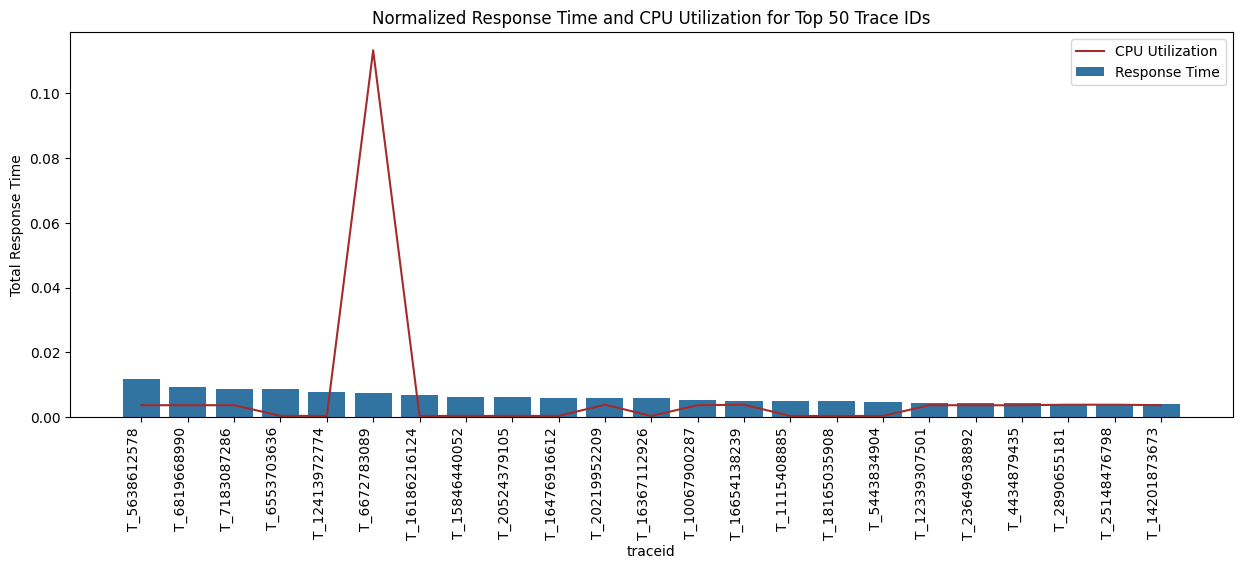

In [145]:
plt.figure(figsize=(15, 5))

sns.barplot(data=sorted_calls_top, x="traceid", y="normalized_rt",label = 'Response Time') 
sns.lineplot(data=top_cpu_utils, x="traceid", y="norm_cpu_util",label = 'CPU Utilization',color = 'brown') 

plt.xticks(rotation=90, ha='right') 
plt.title("Normalized Response Time and CPU Utilization for Top 50 Trace IDs")
plt.xlabel('traceid')
plt.ylabel('Total Response Time')

Text(0, 0.5, 'Total Response Time')

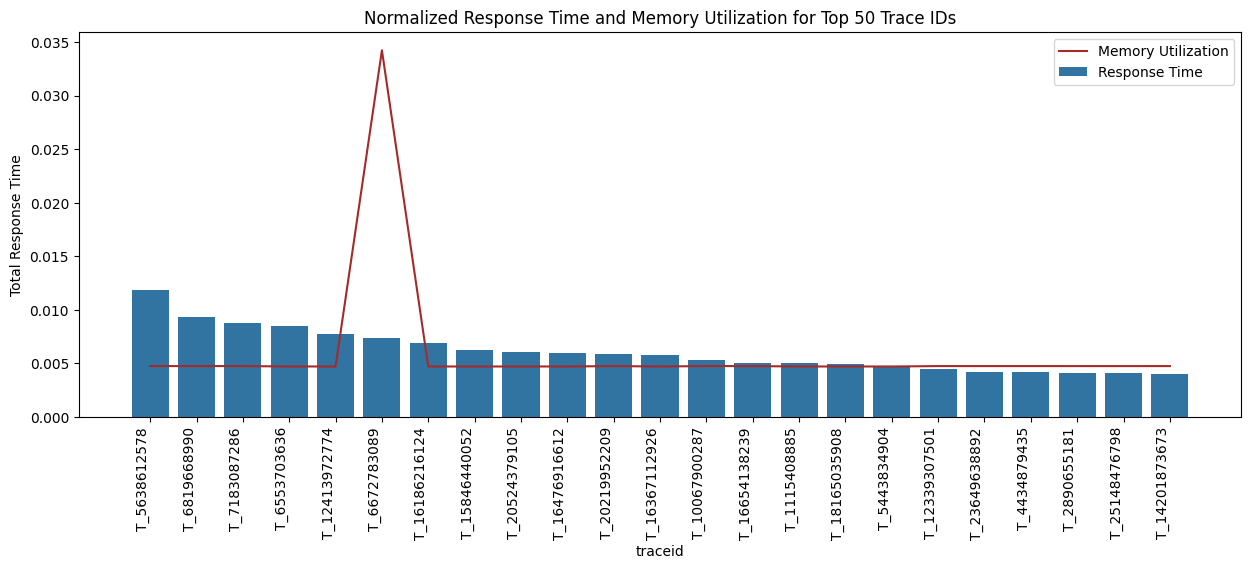

In [143]:
plt.figure(figsize=(15, 5))

sns.barplot(data=sorted_calls_top, x="traceid", y="normalized_rt",label = 'Response Time') 
sns.lineplot(data = top_mem_utils, x="traceid", y="norm_mem_util",label = 'Memory Utilization',color='brown')

plt.xticks(rotation=90, ha='right') 
plt.title("Normalized Response Time and Memory Utilization for Top 50 Trace IDs")
plt.xlabel('traceid')
plt.ylabel('Total Response Time')

In [125]:
traceid = top_nodes_rt.head(15)['traceid']

In [126]:
node_res_data = node_resource_data[node_resource_data['traceid'].isin(traceid)]


In [127]:
node_res_data['normalized_calls'] = node_res_data['normalized_calls']*1000

In [128]:
node_res_data

,nodeid,node_cpu,node_mem,traceid,avg_rt,normalized_rt,incoming_calls,normalized_calls
1,NODE_14394,0.470681,0.385712,T_23269924439,1.666667,0.003936,30,0.178838
2,NODE_15154,0.072100,0.067236,T_23048107203,1.000000,0.002362,30,0.178838
4,NODE_21180,0.161651,0.191756,T_23048107203,2.000000,0.004723,30,0.178838
5,NODE_22181,0.177830,0.220590,T_5457056849,88.000000,0.207814,30,0.178838
7,NODE_27705,0.351017,0.880202,T_10204574009,57.000000,0.134607,30,0.178838
8,NODE_28915,0.462859,0.608061,T_2038942972,86.333333,0.203878,30,0.178838
9,NODE_32141,0.155258,0.266628,T_7183087286,1.750000,0.004133,30,0.178838
10,NODE_3392,0.164921,0.289671,T_1696230406,2.000000,0.004723,30,0.178838
11,NODE_34353,0.204616,0.307203,T_3753288546,5.500000,0.012988,30,0.178838
12,NODE_34790,0.226081,0.145273,T_9171573673,113.000000,0.266852,52,0.309985


In [134]:
top_nodes_rt

,nodeid,traceid,avg_rt,normalized_rt
15,NODE_34790,T_9171573673,113.000000,0.266852
8,NODE_22181,T_5457056849,88.000000,0.207814
11,NODE_28915,T_2038942972,86.333333,0.203878
10,NODE_27705,T_10204574009,57.000000,0.134607
6,NODE_20113,T_6672783089,22.000000,0.051953
21,NODE_9113,T_23048107203,18.714286,0.044194
22,NODE_9787,T_23048107203,10.000000,0.023615
14,NODE_34353,T_3753288546,5.500000,0.012988
17,NODE_3747,T_1696230406,4.000000,0.009446
20,NODE_46414,T_18165035908,3.000000,0.007085


In [138]:
top_nodes_rt.head(15)['normalized_rt'].max()

np.float64(0.26685183987765076)

In [149]:
node_res_data[node_res_data['traceid'].isin(top_nodes_rt['traceid'].head(15))].groupby('nodeid')

C:\Users\prasa\AppData\Local\Temp\ipykernel_19052\1476581758.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=top_nodes_rt.head(15), x="traceid", y="normalized_rt",label = 'Response Time',ci= None)


Text(0, 0.5, 'Total Response Time')

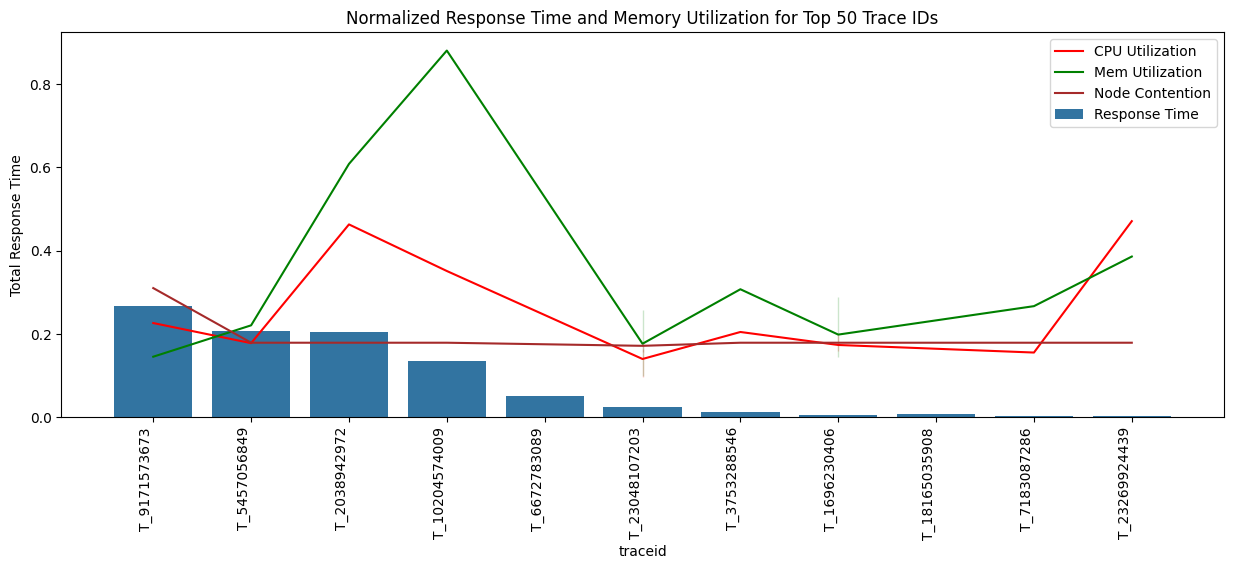

In [146]:
plt.figure(figsize=(15, 5))

sns.barplot(data=top_nodes_rt.head(15), x="traceid", y="normalized_rt",label = 'Response Time',ci= None) 
sns.lineplot(data = node_res_data, x="traceid", y="node_cpu",label = 'CPU Utilization',color='red')
sns.lineplot(data = node_res_data, x="traceid", y="node_mem",label = 'Mem Utilization',color = 'green')
sns.lineplot(data = node_res_data, x="traceid", y="normalized_calls",label = 'Node Contention',color = 'brown')

plt.xticks(rotation=90, ha='right') 
plt.title("Normalized Response Time and Memory Utilization for Top 50 Trace IDs")
plt.xlabel('traceid')
plt.ylabel('Total Response Time')

### From Above Graphs We can Conclude that in an Bigger Picture Overall there are two things that are causing the response rate to be high
#### 1. Microservice Memory Utilization
#### 2. Node Contention

In [157]:
top_node_id = top_nodes_rt.head(15).iloc[0,0]

In [159]:
top_node_id

'NODE_34790'

In [160]:
call_sample.head(5)

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt
0,76237,T_21388589380,S_115042431,0.1.3.27,mc,MS_48385,MS_48385_POD_3776,j9JPeZqdfa,MS_14728,UNKNOWN,0.0
1,104310,T_4767157225,S_104419129,0.1.2.15,mc,MS_4660,MS_4660_POD_2652,27LLHBLtvK,MS_46825,MS_46825_POD_289,1.0
2,35589,T_19429784845,S_58367703,0.1.1.6,mq,MS_19279,MS_19279_POD_91,hMOAwKKkMh,MS_30234,MS_30234_POD_76,0.0
3,80083,T_8925144016,S_80466277,0.1.1.2.1.56.1,mc,MS_51052,MS_51052_POD_2061,K7owOgUd1X,MS_66332,MS_66332_POD_40,0.0
4,44789,T_3037066685,S_104419129,0.1.2.5,mc,MS_4660,MS_4660_POD_1359,ScFx7XudDg,MS_55085,MS_55085_POD_700,0.0


In [161]:
sorted_calls.head(5)

,traceid,rt,normalized_rt
2675,T_9711073466,503.0,0.013376
2189,T_5638612578,445.0,0.011833
1508,T_22889761847,352.0,0.009360
2327,T_6819668990,351.0,0.009334
372,T_13245063790,347.0,0.009227


In [163]:
df_joined_call_sample.head(5)

,timestamp,traceid,service,rpc_id,rpctype,um,uminstanceid,interface,dm,dminstanceid,rt,timestamp_ms,msname,msinstanceid,nodeid,cpu_utilization,memory_utilization,no_of_ms_per_node
0,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,180000,MS_32135,MS_32135_POD_18,NODE_33562,0.217680,0.662040,0.000358
1,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,1080000,MS_32135,MS_32135_POD_18,NODE_33562,0.203220,0.661371,0.000358
2,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,1200000,MS_32135,MS_32135_POD_18,NODE_33562,0.220260,0.661444,0.000358
3,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,1680000,MS_32135,MS_32135_POD_18,NODE_33562,0.190058,0.660943,0.000358
4,42651,T_13276388493,S_152913194,0.1.1,mc,MS_54249,MS_54249_POD_86,qnYHddrfzU,MS_32135,MS_32135_POD_18,1.0,60000,MS_32135,MS_32135_POD_18,NODE_33562,0.196080,0.661718,0.000358
